In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('InsuranceData.csv')

In [4]:
df.describe

<bound method NDFrame.describe of       PolicyNumber CustomerID  Gender  Age PolicyType PolicyStartDate  \
0               P1         C1  Female   73       Auto      13-02-2024   
1               P2         C2    Male   44     Travel      03-03-2024   
2               P3         C3  Female   28     Travel      15-06-2024   
3               P4         C4    Male   85     Travel      03-06-2024   
4               P5         C5  Female   57     Travel      13-06-2024   
...            ...        ...     ...  ...        ...             ...   
9999        P10000     C10000    Male   44       Life      31-07-2023   
10000           P1         C1  Female   73       Auto      13-02-2024   
10001           P2         C2    Male   44     Travel      03-03-2024   
10002           P2         C2    Male   44     Travel      03-03-2024   
10003           P4         C4    Male   85     Travel      03-06-2024   

      PolicyEndDate  PremiumAmount  CoverageAmount ClaimNumber   ClaimDate  \
0        13

In [12]:
df[df.duplicated()]

,PolicyNumber,CustomerID,Gender,Age,PolicyType,PolicyStartDate,PolicyEndDate,PremiumAmount,CoverageAmount,ClaimNumber,ClaimDate,ClaimAmount,ClaimStatus
10000,P1,C1,Female,73,Auto,13-02-2024,13-02-2025,240.64,33175.10,C1,NaN,0.00,Rejected
10001,P2,C2,Male,44,Travel,03-03-2024,03-03-2025,1059.73,85046.42,C2,22-06-2024,1493.06,Pending
10002,P2,C2,Male,44,Travel,03-03-2024,03-03-2025,1059.73,85046.42,C2,22-06-2024,1493.06,Pending
10003,P4,C4,Male,85,Travel,03-06-2024,03-06-2025,549.70,17053.27,C4,25-02-2025,5021.34,Pending


In [13]:
df.drop_duplicates()

,PolicyNumber,CustomerID,Gender,Age,PolicyType,PolicyStartDate,PolicyEndDate,PremiumAmount,CoverageAmount,ClaimNumber,ClaimDate,ClaimAmount,ClaimStatus
0,P1,C1,Female,73,Auto,13-02-2024,13-02-2025,240.64,33175.10,C1,NaN,0.00,Rejected
1,P2,C2,Male,44,Travel,03-03-2024,03-03-2025,1059.73,85046.42,C2,22-06-2024,1493.06,Pending
2,P3,C3,Female,28,Travel,15-06-2024,15-06-2025,1019.59,68525.53,C3,NaN,0.00,Rejected
3,P4,C4,Male,85,Travel,03-06-2024,03-06-2025,549.70,17053.27,C4,25-02-2025,5021.34,Pending
4,P5,C5,Female,57,Travel,13-06-2024,13-06-2025,841.15,55007.27,C5,30-11-2024,1347.46,Pending
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,P9996,C9996,Male,79,Travel,03-01-2024,03-01-2025,1085.07,29491.40,C9996,05-04-2024,5027.52,Settled
9996,P9997,C9997,Female,43,Travel,11-02-2024,11-02-2025,308.46,82666.01,C9997,NaN,0.00,Rejected
9997,P9998,C9998,Male,67,Health,04-05-2024,04-05-2025,157.89,70666.34,C9998,15-07-2024,3597.03,Settled
9998,P9999,C9999,Female,71,Travel,21-09-2023,21-09-2024,817.47,43487.91,C9999,NaN,0.00,Rejected


In [14]:
df.isnull().sum()

PolicyNumber          0
CustomerID            0
Gender                0
Age                   0
PolicyType            0
PolicyStartDate       0
PolicyEndDate         0
PremiumAmount         0
CoverageAmount        0
ClaimNumber           0
ClaimDate          4355
ClaimAmount           0
ClaimStatus           0
dtype: int64

In [15]:
df['ClaimDate'].isnull().sum()

np.int64(4355)

In [16]:
# which policy type is most profitable
premium = df.groupby("PolicyType")['PremiumAmount'].sum()

claim = df.groupby("PolicyType")['ClaimAmount'].sum()

loss_ratio = (claim / premium) * 100 
print(loss_ratio.sort_values(ascending=False))

PolicyType
Travel    286.356916
Health    286.091661
Auto      283.826444
Life      280.751162
Home      264.097209
dtype: float64


In [18]:
# Policies have high Claim Amounts?

Q1 = df['ClaimAmount'].quantile(0.25)
Q3 = df['ClaimAmount'].quantile(0.75)

IQR = Q3 - Q1

upper_limit = Q3 + 1.5 * IQR

high_claims = df[df["ClaimAmount"] > upper_limit]
print(high_claims[['PolicyNumber', "PolicyType" , "CustomerID" , "ClaimAmount"]])

# hense there are not an outliers 


Empty DataFrame
Columns: [PolicyNumber, PolicyType, CustomerID, ClaimAmount]
Index: []


<Axes: ylabel='ClaimAmount'>

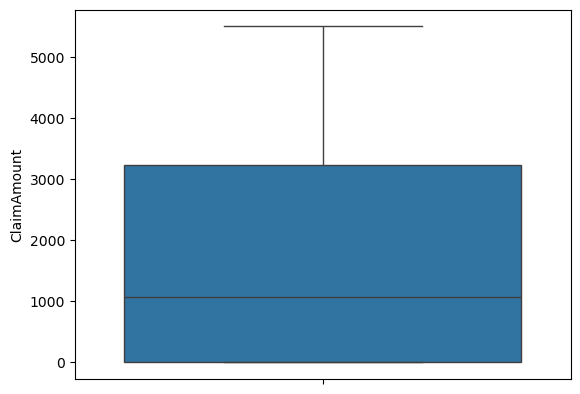

In [19]:
sns.boxplot(df["ClaimAmount"])

Correlation : -0.009421538822138233


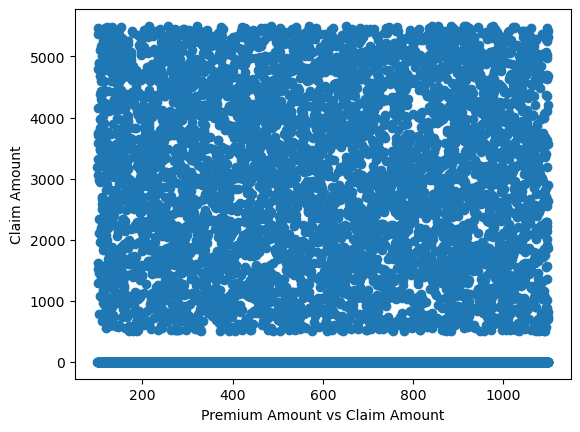

In [20]:
# cheaking the correlation between claim amount and primium 

correlation = df['PremiumAmount'].corr(df['ClaimAmount'])
print("Correlation :" , correlation)

plt.scatter(df['PremiumAmount'] , df['ClaimAmount'])
plt.ylabel("Claim Amount")
plt.xlabel("Premium Amount vs Claim Amount")
plt.show()

# Insight: Premium and Claim amount have almost no linear relationship in this datasert.

Text(0, 0.5, 'Average Claim Amount')

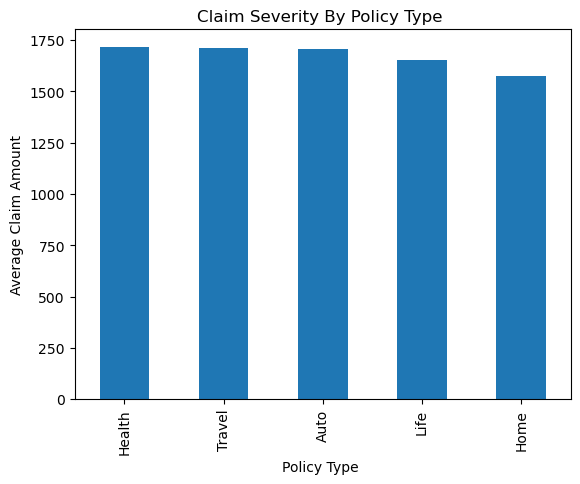

In [27]:
#  Policy which have the highest claim severity 
claim_severity = df.groupby("PolicyType")['ClaimAmount'].mean()

claim_severity.sort_values(ascending=False).plot(kind='bar')
plt.title("Claim Severity By Policy Type ")
plt.xlabel("Policy Type ")
plt.ylabel("Average Claim Amount")

In [21]:
df['Age Group'] = pd.cut(df['Age'] , bins = [0,25,35,45,55,100],
labels = ["18-25" , "26-35" , "36-45" , "46-55" ,"56+"])

claim_by_age = df.groupby("Age Group")['ClaimAmount'].sum()
print(claim_by_age.sort_values(ascending = False))

# Insight = 56+ age group have a highest claim amount 

Age Group
56+      7659421.42
36-45    2575900.30
46-55    2438620.52
26-35    2303455.52
18-25    1934904.97
Name: ClaimAmount, dtype: float64


C:\Users\91860\AppData\Local\Temp\ipykernel_8216\1528389651.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  claim_by_age = df.groupby("Age Group")['ClaimAmount'].sum()


Text(0.5, 1.0, 'Total Claim Amount by Age Group')

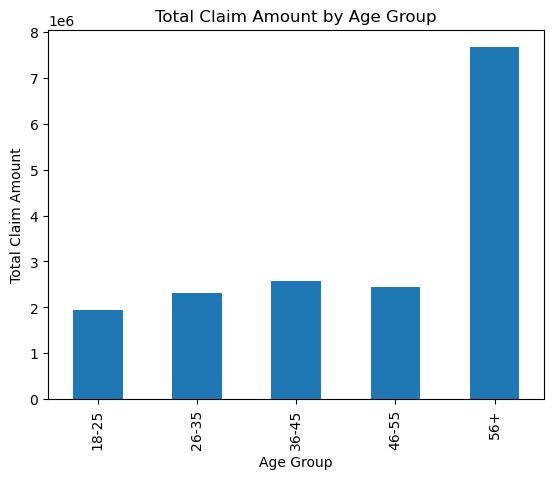

In [24]:
claim_by_age.plot(kind= "bar")
plt.xlabel("Age Group")
plt.ylabel("Total Claim Amount")
plt.title("Total Claim Amount by Age Group")

In [ ]:
claim_Frequency = df.groupby("Age Group")['ClaimAmount'].count()
print(claim_Frequency)

# Insight = 56+ age group have more frequent claim

Age Group
18-25    1161
26-35    1437
36-45    1463
46-55    1429
56+      4514
Name: ClaimAmount, dtype: int64


C:\Users\91860\AppData\Local\Temp\ipykernel_6264\1023578596.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  claim_Frequency = df.groupby("Age Group")['ClaimAmount'].count()


## Overall Conclusion

The analysis provided meaningful insights into the insurance portfolio and helped identify key areas of financial and customer risk:

1.Loss Ratio Analysis: Identified policy types where claim costs are high relative to premiums collected, highlighting areas of increased financial risk.

2.High Claim Analysis: Identified policies with unusually high claim amounts that may require further investigation and risk assessment.

3.Premium vs. Claim Relationship: The correlation of approximately -0.009 indicates almost no linear relationship between premium and claim amounts in the dataset.

4.Age Group Risk Analysis: Age-based segmentation helped identify customer groups with higher claim amounts, claim frequency, and overall financial risk.

5.Claim Severity Analysis: Compared average claim amounts across policy types to identify policies with higher claim severity.

6.Coverage-to-Premium Analysis: Identified policies with unusually high coverage relative to the premium paid, which can be considered potential anomalies for further investigation.

### Final Insight

Overall, the analysis provides a comprehensive view of  financial risk, claim behavior, policy performance, and customer segments**. These insights can help insurance companies improve risk monitoring, policy evaluation, anomaly detection, and data-driven decision-making.
